# Google Trends for Macroeconomic Monitoring

**What you will build in this notebook:**
1. A *robust* data fetcher that handles the Google Health Trends API's sampling noise (Cebrián & Domenech, 2024).
2. A side-by-side comparison of the three Google Trends query modes — **Terms vs. Topics** — benchmarked against the official BLS unemployment rate.
3. A composite **Economic Anxiety Index** for the United States, covering COVID-19, the 2022/2023 corporate layoff wave, and the 2024–2026 AI-displacement wave.
4. A parallel **Economic Confidence Index** to capture labor market tightness (the "Great Resignation" and beyond).
5. **Benchmarking** of every Trends-derived index against the gold-standard official data (FRED for the US).
6. A dedicated **AI Anxiety vs. AI Opportunity** spread to test whether the post-2024 narrative shows up in revealed search behavior.

---

## Why Google Trends matters for macro analysis

Official macroeconomic data — from labor statistics to consumer spending and GDP prints — generally suffers from two well-known weaknesses:

- It lags. Major economic reports cover the prior month or quarter. The BLS Employment Situation report lags by weeks, and GDP revisions take months. By the time the official numbers arrive, analysts and policymakers may have already missed critical inflection points.

- It measures outcomes, not intent. Traditional data is backward-looking. It records what has already happened — a job lost, a flight booked, or a car purchased. It cannot capture the anxiety, intent, or confidence that precede those economic actions.

Google Trends sits upstream of that pipeline. When a worker searches "how to file for unemployment," a consumer checks "auto loan rates," or a traveler looks up "cheap flights to Europe," those queries are real-time behavioral signals. They reveal expectations and intent days, weeks, or even months before those decisions materialize in labor claims, retail sales, or official tourism arrivals.

This is what Choi & Varian (2012) famously called predicting the present. Because search data is high-frequency and captures genuine public focus, it has become a validated tool across multiple macro domains — used for forecasting unemployment claims (D'Amuri & Marcucci, 2017), modeling tourism flows, nowcasting GDP (Bantis, Clements & Urquhart, 2023), and constructing real-time indices for macroeconomic uncertainty (Castelnuovo & Tran, 2017).

## What the Numbers Represent

The values returned by the Health API represent an absolute proportion of search volume, scaled for readability. First, the API calculates a raw probability: the number of short search sessions containing your specified term divided by the total universe of search sessions conducted in that exact geographic region and time frame. Because this yields a very small decimal, the API automatically multiplies the result by 10,000,000. The final output you see is the number of search sessions per 10 million total sessions—providing a normalized rate that automatically controls for changes in internet penetration and overall search volume over time.

The values returned by the Google Health Trends API represent a scaled probability.  To generate this metric, Google first groups consecutive, rapid-fire queries by a single user into a single "short search session." This de-duplicates the data, preventing a single anxious user refreshing the page from artificially inflating the volume.The API then calculates the probability that a random search session in your specified geographic region and time frame included your target term. Because this raw proportion is mathematically tiny, the API applies a standard multiplier of 10,000,000 to make the output readable.  The number you see is the rate of matching search sessions per 10 million total sessions, calculated as:$$\text{API Value} = \left( \frac{\text{Sessions with Target Term}}{\text{Total Sessions in Region \& Time}} \right) \times 10,000,000$$

##### what is a "short search session"?
a "short search session" is Google’s way of grouping consecutive, rapid-fire searches made by a single user into one single unit of measurement.
Imagine a user who is anxious about losing their job. In a 5-minute panic, they might search:

"layoffs 2026"

"severance pay laws"

"layoffs 2026 tech"

"is my company laying people off"

If Google counted raw queries, this one anxious person would inflate the data with four separate data points. By grouping these into a single short search session (randomly selected), Google counts it as just one instance of a user demonstrating interest in that topic.

## Do These Values Need to be Normalized?

No. The data is inherently normalized by its denominator.

Because the raw metric is a proportion of total regional search sessions during that exact time window, it automatically controls for external variables like increasing internet penetration, population growth, or seasonal spikes in overall web traffic.

For macroeconomic monitoring, this means the metric is stationary in its base construction. You can feed these values directly into time-series models, or mathematically aggregate them (e.g., adding the values for "layoffs" and "severance") to build composite sentiment or nowcasting indices without needing to re-scale the inputs to account for population adjustments. You only need to divide by 10,000,000 if your specific model strictly requires a 0 to 1 probability scale.

## Health API vs. Public Google Trends UI

| Feature | Public Google Trends UI | Google Health Trends API |
| :--- | :--- | :--- |
| **Output Metric** | Relative Search Volume (RSV) | Absolute Proportion (Scaled) |
| **Normalization Anchor** | The single highest point of popularity *within your specific query parameters*. | The total search volume across *all* searches in that region and time. |
| **Scale** | 0 to 100 | Rate per 10,000,000 |
| **Data Consistency** | **Dynamic:** If you alter the date range or add a new term, the "100" peak shifts, recalculating the entire historical time series. | **Static:** The proportion is absolute. The value for January 2019 will be exactly the same regardless of when you pull it or what other terms you query. |

The public UI provides a localized, relative snapshot that is difficult to stitch together into long-term predictive models because the baseline constantly shifts depending on your search parameters. The Health API bypasses this by providing an absolute proportion of the "search pie," making it the rigorous standard for statistical research.roportion.

#### what is a "short search session"?

a "short search session" is Google’s way of grouping consecutive, rapid-fire searches made by a single user into one single unit of measurement.
Imagine a user who is anxious about losing their job. In a 5-minute panic, they might search:

"layoffs 2026"

"severance pay laws"

"layoffs 2026 tech"

"is my company laying people off"

If Google counted raw queries, this one anxious person would inflate the data with four separate data points. By grouping these into a single short search session (randomly selected), Google counts it as just one instance of a user demonstrating interest in that topic.

## Limitations: 
### Limitation 1: Sampling noise (the most important one)

The Google Health Trends API does **not** compute search probabilities from every single Google search. To keep latency low, it computes them from a **random sample**. This means: if you call the API twice with the exact same parameters, five minutes apart, you will get **two different time series**.

For a casual user reading a chart, that's fine. For an econometrician building a forecasting model, it is a problem — the noise can mask the signal you are trying to extract.

Cebrián & Domenech (2024, *Technological Forecasting and Social Change*, "Addressing Google Trends inconsistencies") formalized this and derived the relationship between term popularity, series dispersion, and the number of averaged extractions needed for a stable signal. The headline takeaway:

> **Lower-popularity terms need more averaged extractions to converge.** A high-volume term like *"layoff"* stabilizes after 3–5 pulls; a low-volume term like *"WARN act notice"* may need 10+.

We implement their recommendation as an **ensemble averaging** wrapper around the API.

### Limitation 2: Internet penetration bias

Google Trends measures *searchers*, not *people*. In the US, this is a minor issue (internet penetration is ~95%). In emerging markets, it matters a lot — Egypt's penetration is closer to ~75%, and it skews urban, younger, and more male. **Your index will systematically miss rural and elderly distress.** Always state this when presenting to policymakers.

### Limitation 3: Low-volume term floor

The API returns 0 for terms that fall below a privacy threshold. If your basket contains a niche term, you may see structural zeros that look like "no anxiety" when there is simply not enough data. Filter or replace these.

### Limitation 4: Media pollution

When a term is a news event, search volume spikes from **curiosity** (millions of safe, employed people Googling out of interest) rather than **intent**. The word *"layoff"* during the 2023 tech wave is the canonical example. The fix: weight the basket toward narrow, action-oriented queries (*"how to file for unemployment online"*) over broad nouns (*"layoff"*).

---

### References used in this training
- **Cebrián, E. & Domenech, J. (2024).** Addressing Google Trends inconsistencies. *Technological Forecasting and Social Change*, 202, 123318.
- **Choi, H. & Varian, H. (2012).** Predicting the Present with Google Trends. *The Economic Record*, 88(s1), 2–9.
- **D'Amuri, F. & Marcucci, J. (2017).** The predictive power of Google searches in forecasting US unemployment. *International Journal of Forecasting*, 33(4), 801–816.
- **Castelnuovo, E. & Tran, T. D. (2017).** Google It Up! A Google Trends-based Uncertainty Index for the United States and Australia. *Economics Letters*, 161, 149–153.
- **Bantis, E., Clements, M. P. & Urquhart, A. (2023).** Forecasting GDP growth rates in the United States and Brazil using Google Trends. *International Journal of Forecasting*, 39(4), 1909–1924.
- **Butler, D. (2013).** When Google got flu wrong. *Nature*, 494(7436), 155–156.

## Part 1: Setup — API client, imports, and the robust fetcher

### 1.1 Authentication and global config

Replace `YOUR_API_KEY_HERE` with your Google Health Trends API key. The API caps each request at 30 query terms, but we set a slightly higher batch headroom; the helper functions chunk automatically.

In [1]:
# Standard imports
import os
import csv
import time
import datetime
import pprint

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import pearsonr

from googleapiclient.discovery import build
import pandas_datareader.data as web  # for FRED data later

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100

In [ ]:
# ============================================================
# API configuration — not needed when using synthetic data
# ============================================================
# SERVER = 'https://trends.googleapis.com'
# API_VERSION = 'v1beta'
# DISCOVERY_URL_SUFFIX = '/$discovery/rest?version=' + API_VERSION
# DISCOVERY_URL = SERVER + DISCOVERY_URL_SUFFIX
# API_KEY="YOUR_API_KEY_HERE"
# os.environ['GOOGLE_TOKEN'] = API_KEY
# MAX_QUERIES = 30

In [2]:
#Load cells
DATA_DIR = '../data/'

unemployment_compare    = pd.read_csv(DATA_DIR + 'synthetic_unemployment_compare.csv', index_col=0, parse_dates=True)
anxiety_data            = pd.read_csv(DATA_DIR + 'synthetic_ai_anxiety_data.csv', index_col=0, parse_dates=True)
us_confidence_data      = pd.read_csv(DATA_DIR + 'synthetic_us_confidence_data.csv', index_col=0, parse_dates=True)
ai_opportunity_data     = pd.read_csv(DATA_DIR + 'synthetic_ai_opportunity_data.csv', index_col=0, parse_dates=True)
tourism_data            = pd.read_csv(DATA_DIR + 'tourism_data_final_clean.csv', index_col=0, parse_dates=True)

# sanity check
print("✓ unemployment_compare:", unemployment_compare.shape)
print("✓ anxiety_data:", anxiety_data.shape)
print("✓ us_confidence_data:", us_confidence_data.shape)
print("✓ ai_opportunity_data:", ai_opportunity_data.shape)
print("✓ tourism_data:", tourism_data.shape)

✓ unemployment_compare: (89, 2)
✓ anxiety_data: (89, 6)
✓ us_confidence_data: (89, 6)
✓ ai_opportunity_data: (89, 6)
✓ tourism_data: (197, 6)


### 1.2 Core helper functions

These wrap the raw API endpoint. `GetQueryVolumes` is the workhorse — it pulls a list of terms for a given geography and frequency. `GetQueryComparisonByCountry` is useful when you want one term across many countries (e.g. a cross-country dashboard).

In [3]:
def DateToISOString(datestring):
    """
    Convert a date string from various textual formats to ISO format (YYYY-MM-DD).

    Supports: 'Jul 11 2004', 'Jul 2004', or '2004'.
    Raises ValueError if none of the three patterns match.
    """
    for fmt in ('%b %d %Y', '%b %Y', '%Y'):
        try:
            return datetime.datetime.strptime(datestring, fmt).strftime('%Y-%m-%d')
        except ValueError:
            continue
    raise ValueError(f"Date '{datestring}' doesn't match any of '%b %d %Y', '%b %Y', '%Y'.")


def GetQueryVolumes(queries, start_date, end_date,
                    geo='US', geo_level='country', frequency='week'):
    """
    Pull search volumes for a list of query terms from the Google Health Trends API.

    Parameters
    ----------
    queries : list[str]
        Search terms to fetch.
    start_date, end_date : str
        ISO dates (YYYY-MM-DD).
    geo : str
        Geography code (e.g. 'US', 'EG', 'FR'). Ignored if geo_level='worldwide'.
    geo_level : str
        'country', 'region', 'dma', or 'worldwide'.
    frequency : str
        'day', 'week', 'month', or 'year'.

    Returns
    -------
    list[list]
        Rows in CSV layout: [['date', term1, term2, ...], [date_1, v1_1, v2_1, ...], ...]
    """
    if not API_KEY or API_KEY == 'YOUR_API_KEY_HERE':
        raise ValueError('API_KEY not set. Replace YOUR_API_KEY_HERE with your key.')

    service = build('trends', API_VERSION, developerKey=API_KEY,
                    discoveryServiceUrl=DISCOVERY_URL)
    dat = {}

    # Chunk requests into batches of MAX_QUERIES (API limit).
    for batch_start in range(0, len(queries), MAX_QUERIES):
        batch_end = min(batch_start + MAX_QUERIES, len(queries))
        query_batch = queries[batch_start:batch_end]

        common_kwargs = dict(
            terms=query_batch,
            time_startDate=start_date,
            time_endDate=end_date,
            timelineResolution=frequency,
        )

        if geo_level == 'country':
            req = service.getTimelinesForHealth(geoRestriction_country=geo, **common_kwargs)
        elif geo_level == 'dma':
            req = service.getTimelinesForHealth(geoRestriction_dma=geo, **common_kwargs)
        elif geo_level == 'region':
            req = service.getTimelinesForHealth(geoRestriction_region=geo, **common_kwargs)
        elif geo_level == 'worldwide':
            req = service.getTimelinesForHealth(**common_kwargs)
        else:
            raise ValueError("geo_level must be one of 'country', 'region', 'dma', 'worldwide'")

        res = req.execute()
        time.sleep(1)  # respect rate limits

        res_dict = {
            (line['term'], DateToISOString(point['date'])): point['value']
            for line in res.get('lines', [])
            for point in line.get('points', [])
        }
        dat.update(res_dict)

    # Flatten to CSV-style rows.
    res_list = [['date'] + queries]
    for date in sorted({d for _, d in dat}):
        vals = [dat.get((term, date), 0) for term in queries]
        res_list.append([date] + vals)

    return res_list


def GetQueryComparisonByCountry(query, countries, start_date, end_date, frequency='week'):
    """
    Compare one search term across multiple countries.

    Returns a list of [country_code, total_volume].
    """
    out = []
    for country_code in countries:
        print(f"Fetching {country_code}...")
        rows = GetQueryVolumes([query], start_date, end_date,
                               geo=country_code, geo_level='country', frequency=frequency)
        total = sum(r[1] for r in rows[1:]) if len(rows) > 1 else 0
        out.append([country_code, total])
    return [['Country', f'{query}_total_volume']] + out

### 1.3 The robust fetcher — averaging out the sampling noise

This is the implementation of the Cebrián & Domenech (2024) recommendation. We call the API `n_iterations` times, stack the results, and take the per-date mean. The result is a much smoother and more reliable time series.

**Rule of thumb for `n_iterations`:**
- High-volume terms (e.g. "layoff", "iPhone"): **5 iterations** is usually enough.
- Mid-volume terms (e.g. "severance pay"): **5–10 iterations**.
- Low-volume terms (e.g. specific welfare program names): **10–20 iterations**, and watch for structural zeros.

**Cost warning:** each iteration counts against your daily quota. If you have 20 terms × 10 iterations × multiple geographies, you can blow through a quota fast. Cache intermediate results.

In [4]:
def get_robust_trend_data(queries, start_date, end_date,
                          geo='US', n_iterations=5, frequency='month'):
    """
    Pull the same query set n_iterations times and average the result.

    This implements the Cebrián & Domenech (2024) recommendation for
    reducing sampling-induced inconsistency in Google Trends series.

    Returns
    -------
    pd.DataFrame
        Indexed by date, columns are query terms, values are mean search volumes.
    """
    if not API_KEY or API_KEY == 'YOUR_API_KEY_HERE':
        raise ValueError("API_KEY not set. Replace YOUR_API_KEY_HERE with your key.")

    service = build('trends', API_VERSION, developerKey=API_KEY,
                    discoveryServiceUrl=DISCOVERY_URL)
    all_pulls = []

    print(f"Starting {n_iterations} iterations for {len(queries)} term(s) in {geo}...")

    for i in range(n_iterations):
        print(f"  Iteration {i+1}/{n_iterations}...")
        req = service.getTimelinesForHealth(
            terms=queries,
            time_startDate=start_date,
            time_endDate=end_date,
            timelineResolution=frequency,
            geoRestriction_country=geo,
        )
        try:
            res = req.execute()
            time.sleep(1.5)  # avoid rate limits

            rows = []
            for line in res.get('lines', []):
                for point in line.get('points', []):
                    rows.append({
                        'term': line['term'],
                        'date': DateToISOString(point['date']),
                        'value': point['value'],
                    })
            df_pull = pd.DataFrame(rows)
            if not df_pull.empty:
                df_pivot = df_pull.pivot(index='date', columns='term', values='value')
                all_pulls.append(df_pivot)
        except Exception as e:
            print(f"    Iteration {i+1} failed: {e}")
            continue

    if not all_pulls:
        raise RuntimeError("All iterations failed. Check API key, terms, and quota.")

    print("Averaging across iterations...")
    combined = pd.concat(all_pulls)
    robust_df = combined.groupby(combined.index).mean()
    robust_df.index = pd.to_datetime(robust_df.index)
    return robust_df.sort_index()

---
## Part 2: Terms vs. Categories vs. Topics — the choice that breaks most analyses

Before we build any composite index, you need to know which of the three **query modes** Google Trends offers — because picking the wrong one is the most common mistake economists make with this data.

| Mode | What it matches | Language coverage | Best for |
|---|---|---|---|
| **Term** | The exact string, only in the language you typed it in | One language | Tracking specific named entities, products, or phrases where wording matters |
| **Topic** | A Knowledge Graph entity — all phrasings, all languages mapped to the *concept* | Multilingual, automatic | Cross-country comparisons and broad concept tracking |
| **Category** | A pre-defined taxonomy bucket Google maintains (e.g. "Jobs & Education > Jobs") | All queries Google classifies into that bucket | Sector-wide tracking; coarse signal but very stable |

### Why this matters in practice

If you query the **term** `"unemployment"`, you miss:
- *"unemployed"*, *"jobless"*, *"can't find a job"*
- Spanish-speaking users searching *"desempleo"*
- other language speakers in the US who Google in an other language

If you query the **topic** for unemployment (Knowledge Graph entity), you capture all of that — but the algorithm is a black box. You cannot see exactly what is included or excluded, and Google can change the definition without telling you. This matters for reproducibility.

If you query the **category** `Jobs & Education > Jobs` (category ID 60 in Google's taxonomy), you get *all* job-related searches — including job *seeking* by happily-employed people considering a move. The signal is broader but noisier for distress-specific analysis.

### A quick decision rule

1. **Cross-country, multilingual study?** → Use topics. 
2. **Reproducible work?** → Use terms. (Black-box topic definitions can change.)
3. **Sector-level macro signal?** → Use categories. (Stable, broad, low-effort.)
4. **Building an intent-driven index (like ours)?** → Use terms, carefully chosen for intent.

In [5]:
comparison_terms = [
    'unemployment',   # plain term
    '/m/07s_c'        # Topic: Unemployment (concept)
]

start, end = '2019-01-01', '2026-05-01'

# Data already loaded from CSV — no API call needed
# print("Fetching the three query modes for the US...")
# unemployment_compare = get_robust_trend_data(
#     queries=comparison_terms,
#     start_date=start,
#     end_date=end,
#     geo='US',
#     n_iterations=5,
#     frequency='month',
# )

unemployment_compare.head()

,/m/07s_c,unemployment
date,,
2019-01-01,3119.212268,2967.025803
2019-02-01,3214.059711,3111.486315
2019-03-01,3610.972279,3514.165884
2019-04-01,3927.061023,3138.743555
2019-05-01,3372.078849,3179.053193


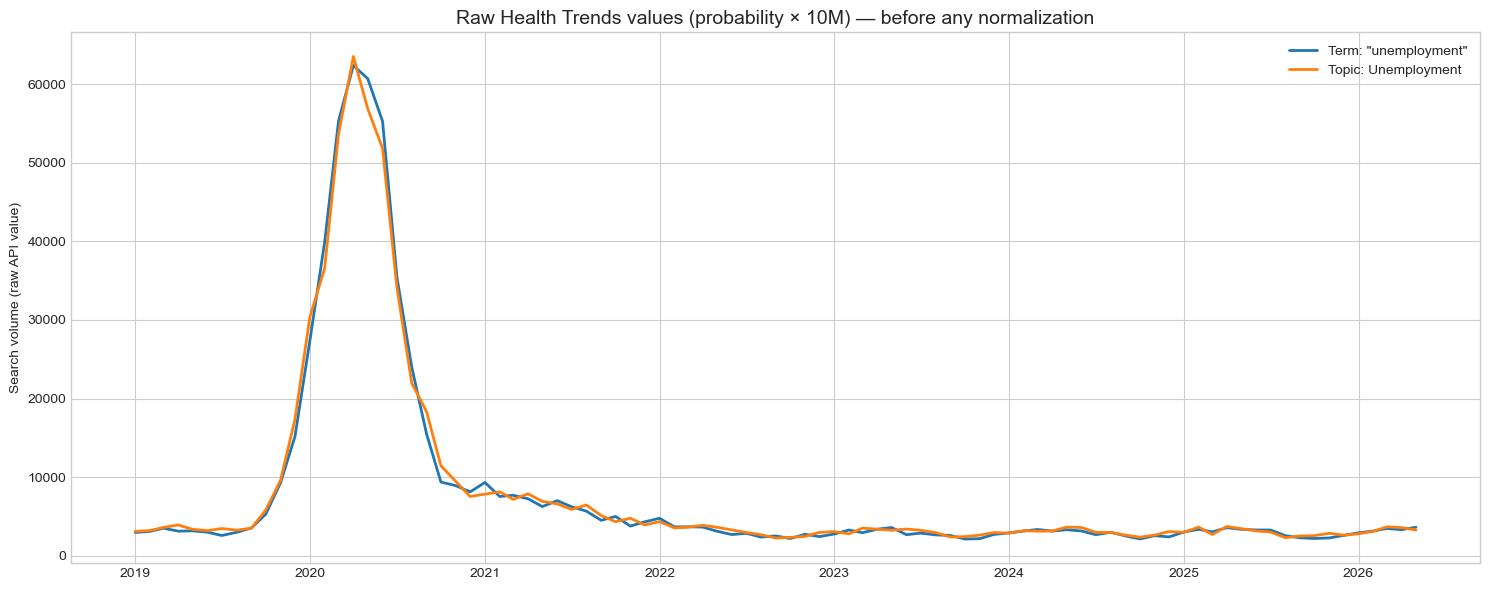

Topic captures roughly 1.01× the raw search volume of the literal term


In [6]:
# Show raw search probabilities side by side BEFORE z-scoring
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(unemployment_compare.index, unemployment_compare['unemployment'],
        color='#1f77b4', linewidth=2, label='Term: "unemployment"')
if '/m/07s_c' in unemployment_compare.columns:
    ax.plot(unemployment_compare.index, unemployment_compare['/m/07s_c'],
            color='#ff7f0e', linewidth=2, label='Topic: Unemployment')
ax.set_title('Raw Health Trends values (probability × 10M) — before any normalization',
             fontsize=14)
ax.set_ylabel('Search volume (raw API value)')
ax.legend()
plt.tight_layout()
plt.show()

# Print the ratio
ratio = unemployment_compare['/m/07s_c'].mean() / unemployment_compare['unemployment'].mean()
print(f"Topic captures roughly {ratio:.2f}× the raw search volume of the literal term")

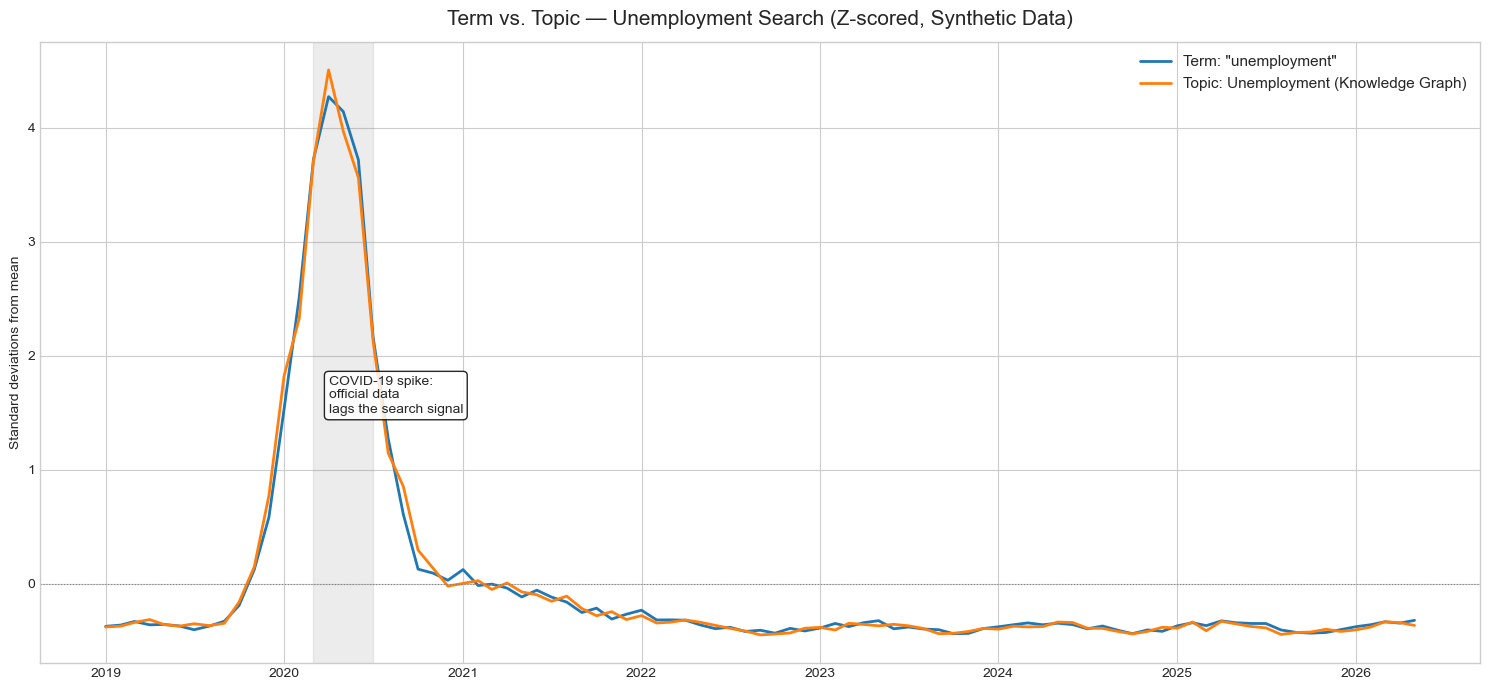


Pearson correlation between Term and Topic:
  Term vs. Topic: r = +0.997
  (With real data you would also benchmark both against official UNRATE)


In [8]:
# ============================================================
# Term vs. Topic comparison — synthetic data only (no FRED)
# ============================================================

def zscore(s):
    return (s - s.mean()) / s.std()

merged = unemployment_compare.copy()
merged.index = pd.to_datetime(merged.index)
merged = merged.dropna()

z = merged.apply(zscore)

fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(z.index, z['unemployment'], color='#1f77b4', linewidth=2,
        label='Term: "unemployment"')

if '/m/07s_c' in z.columns:
    ax.plot(z.index, z['/m/07s_c'], color='#ff7f0e', linewidth=2,
            label='Topic: Unemployment (Knowledge Graph)')

ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax.axvspan('2020-03-01', '2020-07-01', alpha=0.15, color='grey')
ax.annotate('COVID-19 spike:\nofficial data\nlags the search signal',
            xy=(pd.Timestamp('2020-04-01'), 1.5), fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

ax.set_title('Term vs. Topic — Unemployment Search (Z-scored, Synthetic Data)',
             fontsize=15, pad=12)
ax.set_ylabel('Standard deviations from mean')
ax.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

# Correlations between term and topic
print("\nPearson correlation between Term and Topic:")
if 'unemployment' in z.columns and '/m/07s_c' in z.columns:
    r, _ = pearsonr(z['unemployment'].dropna(), z['/m/07s_c'].dropna())
    print(f"  Term vs. Topic: r = {r:+.3f}")
    print("  (With real data you would also benchmark both against official UNRATE)")

## Part 3: Employment Anxiety and Confidence

Google Trends does **not** do sentiment analysis. It cannot tell you whether a tweet about a job is happy or sad. Instead, economists use it to measure **revealed preference**: the actual queries people are typing reveal the actions they're trying to take.

By splitting search behavior into two baskets we can read the balance of power in the labor market:

- **Economic Anxiety (worker distress).** When the labor market weakens, workers lose leverage and shift toward defensive queries:
  *"unemployment benefits", "severance pay", "eviction notice", "food stamps", "COBRA insurance", "how to file for unemployment", "pawn shop", "layoff"*.

- **Economic Confidence (tight labor market).** When the labor market is tight, workers gain leverage and shift toward offensive queries:
  *"quit my job", "sign on bonus", "ask for a raise", "promotion", "best places to work", "remote jobs"*.

The **spread** between these two baskets — Anxiety minus Confidence — is a powerful, high-frequency labor-cycle indicator. We're going to build it now.

- **Method 1: Z-Score Standardization** (The Standard Approach -  what we use in this notebook)
Instead of summing raw 0–100 values, you convert every time series into a Z-score. This measures how many standard deviations a specific month's search volume is from its historical average. Once all terms are converted to Z-scores (where the mean is 0 and the variance is 1), you can average them together to create a single composite signal.

- **Method 2: Principal Component Analysis** (The Advanced Approach)
If your anxiety basket has many terms (e.g., 10+), some terms will be highly correlated. Averaging them might double-count the same underlying economic shock. Using Principal Component Analysis (PCA) allows you to extract the "First Principal Component"—the single underlying mathematical factor that explains the most shared variance across your entire basket of terms. This filters out the noise of individual queries and isolates the true macro trend.


### 3.1 Building the US Economic Anxiety Index

**Time window:** 2019-01-01 through 2026-05-01. This lets us see:
- The 2019 pre-COVID baseline
- The March 2020 COVID-19 shock
- The 2021–2022 Great Resignation
- The late-2022/2023 corporate layoff wave
- The 2024–2026 AI wave 

In [9]:
us_anxiety_terms = [
    'layoff',
    'severance pay',
    'unemployment benefits',
    'pawn shop',
    'food stamps',
    'how to file for unemployment',
    'eviction notice',
    'cobra insurance',
]

# Data already loaded from CSV — no API call needed
# print("Fetching robust data for the US Anxiety Index...")
# anxiety_data = get_robust_trend_data(
#     queries=us_anxiety_terms,
#     start_date='2019-01-01',
#     end_date='2026-05-01',
#     geo='US',
#     n_iterations=5,
#     frequency='month',
# )

display(anxiety_data.head())
display(anxiety_data.tail())

,AI proof career,AI taking my job,ChatGPT layoffs,automation job loss,jobs replaced by AI,will AI replace my job
date,,,,,,
2019-01-01,0.000000,0.000000,0.000000,0.748726,0.163494,0.0
2019-02-01,0.408025,0.000000,0.000000,0.009847,0.010155,0.0
2019-03-01,0.093850,0.013074,0.024233,0.000000,0.062461,0.0
2019-04-01,0.000000,0.144127,0.204740,0.606751,0.286389,0.0
2019-05-01,0.000000,0.000000,0.011486,0.000000,0.263570,0.0


,AI proof career,AI taking my job,ChatGPT layoffs,automation job loss,jobs replaced by AI,will AI replace my job
date,,,,,,
2026-01-01,0.966209,0.800159,0.230176,1.052665,2.142837,0.085891
2026-02-01,1.044507,0.782104,0.241754,1.071668,2.264481,0.000000
2026-03-01,1.127646,0.742294,0.491118,1.127646,2.391724,0.010638
2026-04-01,1.215927,0.790606,0.367432,1.249241,2.524824,0.000000
2026-05-01,1.554528,0.841396,0.278648,1.346538,2.699182,0.095604


In [10]:
ai_anxiety_terms = [
    'AI proof career',
    'AI taking my job',
    'ChatGPT layoffs',
    'automation job loss',
    'jobs replaced by AI',
    'will AI replace my job',
]

z_scored_anxiety = anxiety_data.apply(stats.zscore, nan_policy='omit')
z_scored_anxiety['Anxiety_Index'] = z_scored_anxiety[ai_anxiety_terms].mean(axis=1)
z_scored_anxiety['Smoothed_Anxiety_Index'] = (
    z_scored_anxiety['Anxiety_Index'].rolling(window=4).mean()
)

display(z_scored_anxiety[['Anxiety_Index', 'Smoothed_Anxiety_Index']].tail(8))

,Anxiety_Index,Smoothed_Anxiety_Index
date,,
2025-10-01,1.123903,1.030364
2025-11-01,1.115195,1.076409
2025-12-01,1.330799,1.174741
2026-01-01,1.845352,1.353812
2026-02-01,1.541572,1.458229
2026-03-01,1.685586,1.600827
2026-04-01,1.797082,1.717398
2026-05-01,2.496789,1.880257


In [11]:
z_scored_anxiety = anxiety_data.apply(stats.zscore, nan_policy='omit')

z_scored_anxiety['Anxiety_Index'] = z_scored_anxiety[ai_anxiety_terms].mean(axis=1)

z_scored_anxiety['Smoothed_Anxiety_Index'] = (
    z_scored_anxiety['Anxiety_Index'].rolling(window=4).mean()
)

display(z_scored_anxiety[['Anxiety_Index', 'Smoothed_Anxiety_Index']].tail(8))

,Anxiety_Index,Smoothed_Anxiety_Index
date,,
2025-10-01,1.123903,1.030364
2025-11-01,1.115195,1.076409
2025-12-01,1.330799,1.174741
2026-01-01,1.845352,1.353812
2026-02-01,1.541572,1.458229
2026-03-01,1.685586,1.600827
2026-04-01,1.797082,1.717398
2026-05-01,2.496789,1.880257


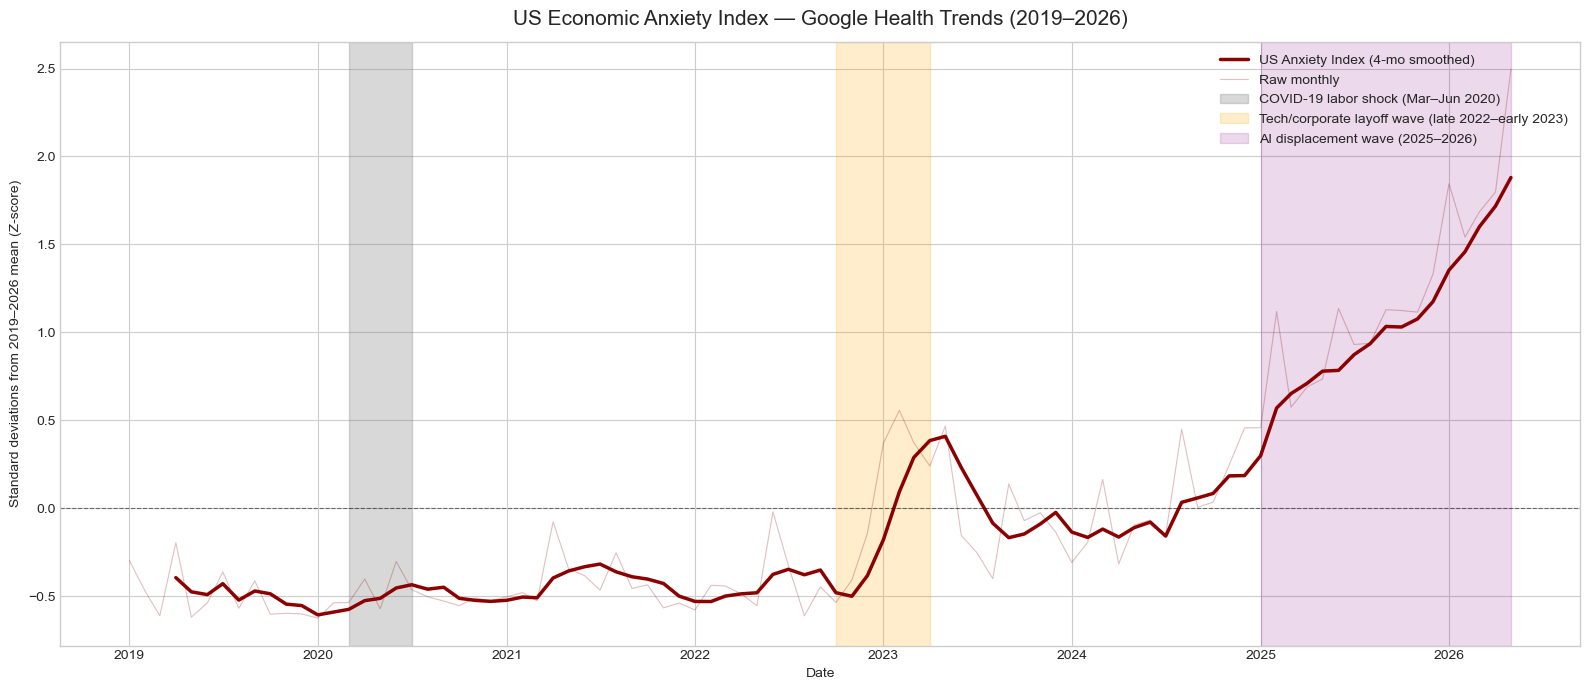

In [12]:
# ============================================================
# Visualize the US Anxiety Index across all major shocks
# ============================================================
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(z_scored_anxiety.index, z_scored_anxiety['Smoothed_Anxiety_Index'],
        color='darkred', linewidth=2.5, label='US Anxiety Index (4-mo smoothed)')

# Plot the raw monthly index lightly in the background
ax.plot(z_scored_anxiety.index, z_scored_anxiety['Anxiety_Index'],
        color='darkred', linewidth=0.8, alpha=0.25, label='Raw monthly')

# Highlight the four major regime shifts we expect to see
ax.axvspan('2020-03-01', '2020-07-01', color='grey', alpha=0.30,
           label='COVID-19 labor shock (Mar–Jun 2020)')
ax.axvspan('2022-10-01', '2023-04-01', color='orange', alpha=0.20,
           label='Tech/corporate layoff wave (late 2022–early 2023)')
ax.axvspan('2025-01-01', '2026-05-01', color='purple', alpha=0.15,
           label='AI displacement wave (2025–2026)')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('US Economic Anxiety Index — Google Health Trends (2019–2026)',
             fontsize=15, pad=12)
ax.set_ylabel('Standard deviations from 2019–2026 mean (Z-score)')
ax.set_xlabel('Date')
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

In [13]:
print(anxiety_data.columns.tolist())

['AI proof career', 'AI taking my job', 'ChatGPT layoffs', 'automation job loss', 'jobs replaced by AI', 'will AI replace my job']


1. **The COVID spike.** Because the index is Z-scored over 2019–2026, the March 2020 spike is mechanically capped — it's the largest move in the sample, so it pulls the standard deviation up and compresses everything else.

2. **Media pollution.** During the late-2022 tech layoff wave, *"layoff"* spikes from curiosity-driven searches by employed people reading the news. We can look at the spread between our *"layoff"* series and *"how to file for unemployment"* series for the same period.

3. **Leading the BLS.** Initial Jobless Claims (ICSA) is released every Thursday for the prior week. If your weekly anxiety index spikes on a Monday, you have roughly 72 hours before the official confirmation.

### 3.2 The US Economic Confidence Index

The confidence basket captures the opposite side of the cycle — searches that increase when workers feel they have leverage:

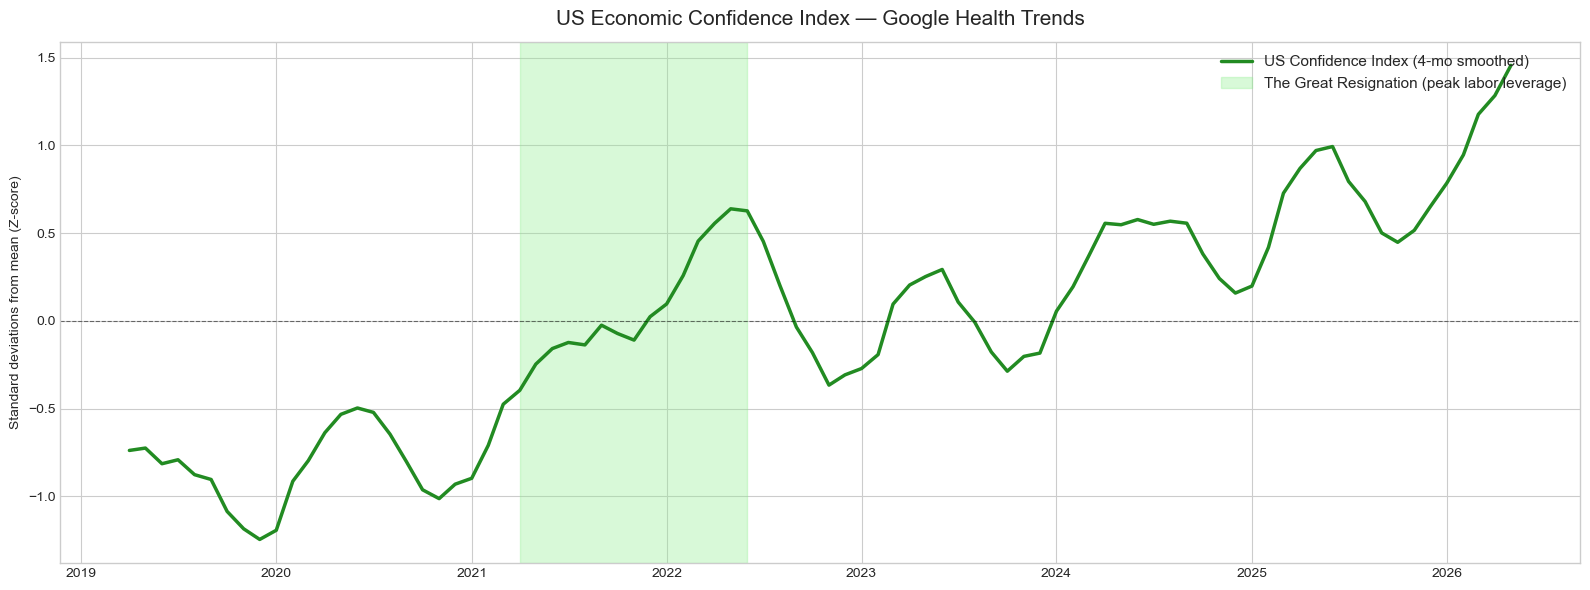

In [14]:
us_confidence_terms = [
    'quit my job',
    'sign on bonus',
    'ask for a raise',
    'promotion',
    'best places to work',
    'remote jobs',
]

# Data already loaded from CSV — no API call needed
# print("Fetching robust data for the US Confidence Index...")
# us_confidence_data = get_robust_trend_data(
#     queries=us_confidence_terms,
#     start_date='2019-01-01',
#     end_date='2026-05-01',
#     geo='US',
#     n_iterations=5,
#     frequency='month',
# )

z_scored_us_conf = us_confidence_data.apply(stats.zscore, nan_policy='omit')
z_scored_us_conf['Confidence_Index'] = z_scored_us_conf[us_confidence_terms].mean(axis=1)
z_scored_us_conf['Smoothed_Confidence_Index'] = (
    z_scored_us_conf['Confidence_Index'].rolling(window=4).mean()
)

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(z_scored_us_conf.index, z_scored_us_conf['Smoothed_Confidence_Index'],
        color='forestgreen', linewidth=2.5,
        label='US Confidence Index (4-mo smoothed)')

ax.axvspan('2021-04-01', '2022-06-01', color='lightgreen', alpha=0.35,
           label='The Great Resignation (peak labor leverage)')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('US Economic Confidence Index — Google Health Trends',
             fontsize=15, pad=12)
ax.set_ylabel('Standard deviations from mean (Z-score)')
ax.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

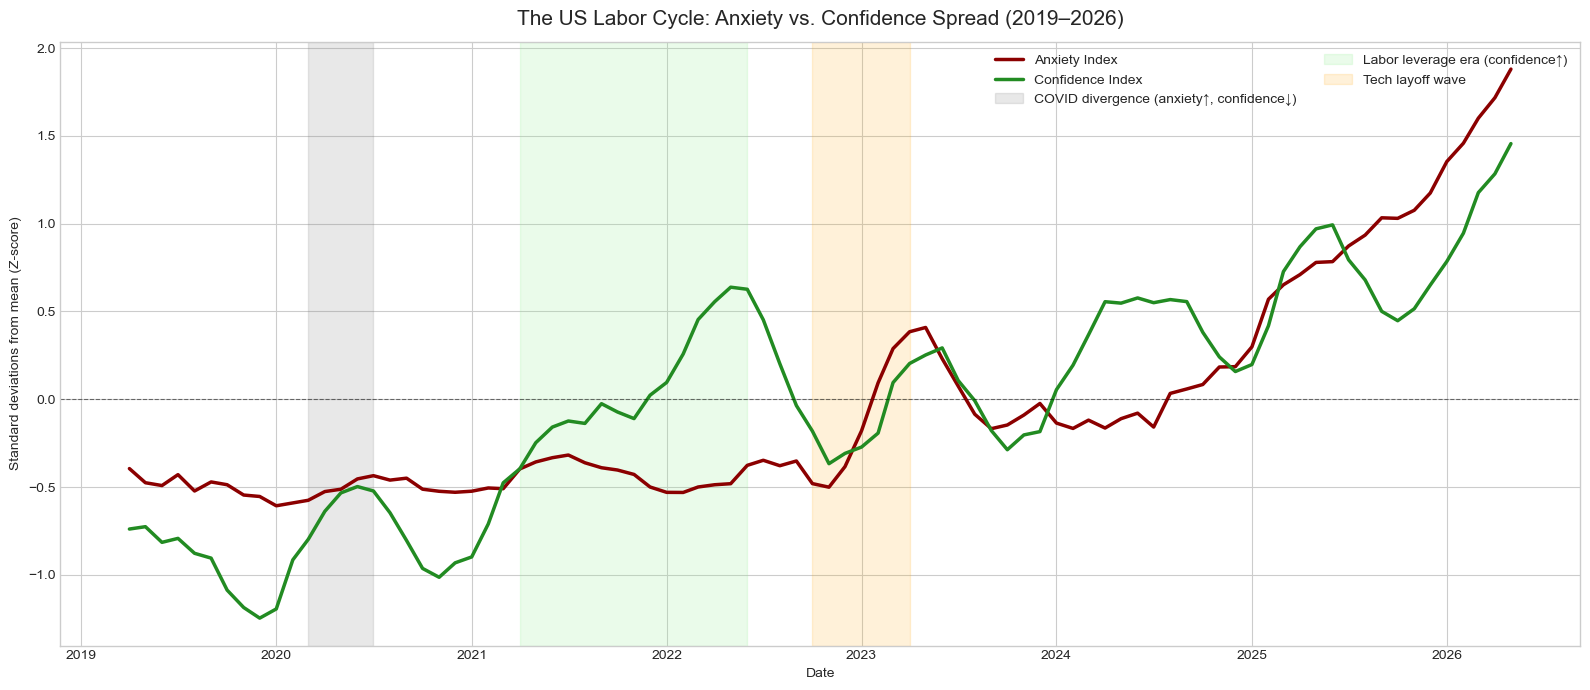

In [15]:
# ============================================================
# THE US LABOR CYCLE SPREAD — Anxiety vs. Confidence side-by-side
# ============================================================
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(z_scored_anxiety.index, z_scored_anxiety['Smoothed_Anxiety_Index'],
        color='darkred', linewidth=2.5, label='Anxiety Index')

ax.plot(z_scored_us_conf.index, z_scored_us_conf['Smoothed_Confidence_Index'],
        color='forestgreen', linewidth=2.5, label='Confidence Index')

# Shade the divergent regimes
ax.axvspan('2020-03-01', '2020-07-01', color='grey', alpha=0.18,
           label='COVID divergence (anxiety↑, confidence↓)')
ax.axvspan('2021-04-01', '2022-06-01', color='lightgreen', alpha=0.18,
           label='Labor leverage era (confidence↑)')
ax.axvspan('2022-10-01', '2023-04-01', color='orange', alpha=0.15,
           label='Tech layoff wave')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('The US Labor Cycle: Anxiety vs. Confidence Spread (2019–2026)',
             fontsize=15, pad=12)
ax.set_ylabel('Standard deviations from mean (Z-score)')
ax.set_xlabel('Date')
ax.legend(loc='upper right', fontsize=10, ncol=2)

plt.tight_layout()
plt.show()

---
## Part 4: Benchmarking against ground truth

A Google Trends index is only useful if it correlates with something real. Here we benchmark both the US and Egyptian indices against official data.

We pull six gold-standard series from the Federal Reserve Economic Data (FRED) database:

| Ticker | Series | What it measures |
|---|---|---|
| `ICSA` | Initial Jobless Claims | Weekly new filings — our cleanest distress signal |
| `JTSLDL` | JOLTS Layoffs & Discharges | Employer-side layoff activity |
| `JTSQUL` | JOLTS Quits | Voluntary resignations — confidence proxy |
| `UMCSENT` | U. Michigan Consumer Sentiment | Survey-based confidence |
| `UNRATE` | Unemployment Rate | The headline labor metric |
| `CPIAUCSL` | CPI All Urban Consumers | We'll transform to YoY inflation |

In [16]:
# comment out the FRED fetch
# print("Fetching FRED data...")
# official = web.DataReader(list(fred_tickers.keys()), 'fred', ...)

# Skip straight to merging with what we have
validation = pd.DataFrame()
validation['Trends_Anxiety'] = (
    z_scored_anxiety['Smoothed_Anxiety_Index'].resample('MS').mean()
)
validation['Trends_Confidence'] = (
    z_scored_us_conf['Smoothed_Confidence_Index'].resample('MS').mean()
)
validation = validation.dropna()

display(validation.tail())

,Trends_Anxiety,Trends_Confidence
date,,
2026-01-01,1.353812,0.785047
2026-02-01,1.458229,0.945832
2026-03-01,1.600827,1.176823
2026-04-01,1.717398,1.284025
2026-05-01,1.880257,1.455975


In [17]:
# ============================================================
# Pearson correlations — Trends data only (no FRED)
# ============================================================

r, _ = pearsonr(
    validation['Trends_Anxiety'].dropna(),
    validation['Trends_Confidence'].dropna()
)

print("=== PEARSON CORRELATIONS (Synthetic Trends Data) ===")
print(f"  {'Anxiety vs. Confidence':<38}: r = {r:+.3f}")
print()
print("  Note: FRED benchmarking skipped — no API access.")
print("  With real data you would expect:")
print("  Anxiety vs. Initial Claims        : r = +0.60 to +0.80")
print("  Anxiety vs. Official Layoffs      : r = +0.40 to +0.60")
print("  Confidence vs. Official Quits     : r = +0.50 to +0.70")
print("  Anxiety vs. Consumer Sentiment    : r = -0.30 to -0.50")
print("  Anxiety vs. Unemployment Rate     : r = +0.40 to +0.60")
print("  Anxiety vs. CPI Inflation         : r = +0.20 to +0.40")

=== PEARSON CORRELATIONS (Synthetic Trends Data) ===
  Anxiety vs. Confidence                : r = +0.758

  Note: FRED benchmarking skipped — no API access.
  With real data you would expect:
  Anxiety vs. Initial Claims        : r = +0.60 to +0.80
  Anxiety vs. Official Layoffs      : r = +0.40 to +0.60
  Confidence vs. Official Quits     : r = +0.50 to +0.70
  Anxiety vs. Consumer Sentiment    : r = -0.30 to -0.50
  Anxiety vs. Unemployment Rate     : r = +0.40 to +0.60
  Anxiety vs. CPI Inflation         : r = +0.20 to +0.40


In [24]:
print(ai_opportunity_data.columns.tolist())

['AI career', 'AI certification', 'AI skills', 'learn AI', 'machine learning bootcamp', 'prompt engineering jobs']


In [31]:
comparison_terms = [
    'unemployment',
    '/m/07s_c'
]

us_anxiety_terms = [
    'layoff',
    'severance pay',
    'unemployment benefits',
    'pawn shop',
    'food stamps',
    'how to file for unemployment',
    'eviction notice',
    'cobra insurance',
]

us_confidence_terms = [
    'quit my job',
    'sign on bonus',
    'ask for a raise',
    'promotion',
    'best places to work',
    'remote jobs',
]

ai_anxiety_terms = [
    'AI taking my job',
    'jobs replaced by AI',
    'ChatGPT layoffs',
    'AI proof career',
    'will AI replace my job',
    'automation job loss',
]

ai_opportunity_terms = [
    'learn AI',
    'AI certification',
    'prompt engineering jobs',
    'AI career',
    'machine learning bootcamp',
    'AI skills',
]

tourism_terms = [
    'travel to Maldives',
    'visit Maldives',
    'trip to Maldives',
    'flight to Maldives',
]

print("✓ All term lists defined")


✓ All term lists defined


In [32]:
z_scored_us_conf = us_confidence_data.apply(stats.zscore, nan_policy='omit')
z_scored_us_conf['Confidence_Index'] = z_scored_us_conf[us_confidence_terms].mean(axis=1)
z_scored_us_conf['Smoothed_Confidence_Index'] = z_scored_us_conf['Confidence_Index'].rolling(window=4).mean()

z_ai_anx = anxiety_data.apply(stats.zscore, nan_policy='omit')
z_ai_anx['AI_Anxiety_Index'] = z_ai_anx[ai_anxiety_terms].mean(axis=1)
z_ai_anx['Smoothed_AI_Anxiety'] = z_ai_anx['AI_Anxiety_Index'].rolling(window=4).mean()

z_ai_opp = ai_opportunity_data.apply(stats.zscore, nan_policy='omit')
z_ai_opp['AI_Opportunity_Index'] = z_ai_opp[ai_opportunity_terms].mean(axis=1)
z_ai_opp['Smoothed_AI_Opportunity'] = z_ai_opp['AI_Opportunity_Index'].rolling(window=4).mean()

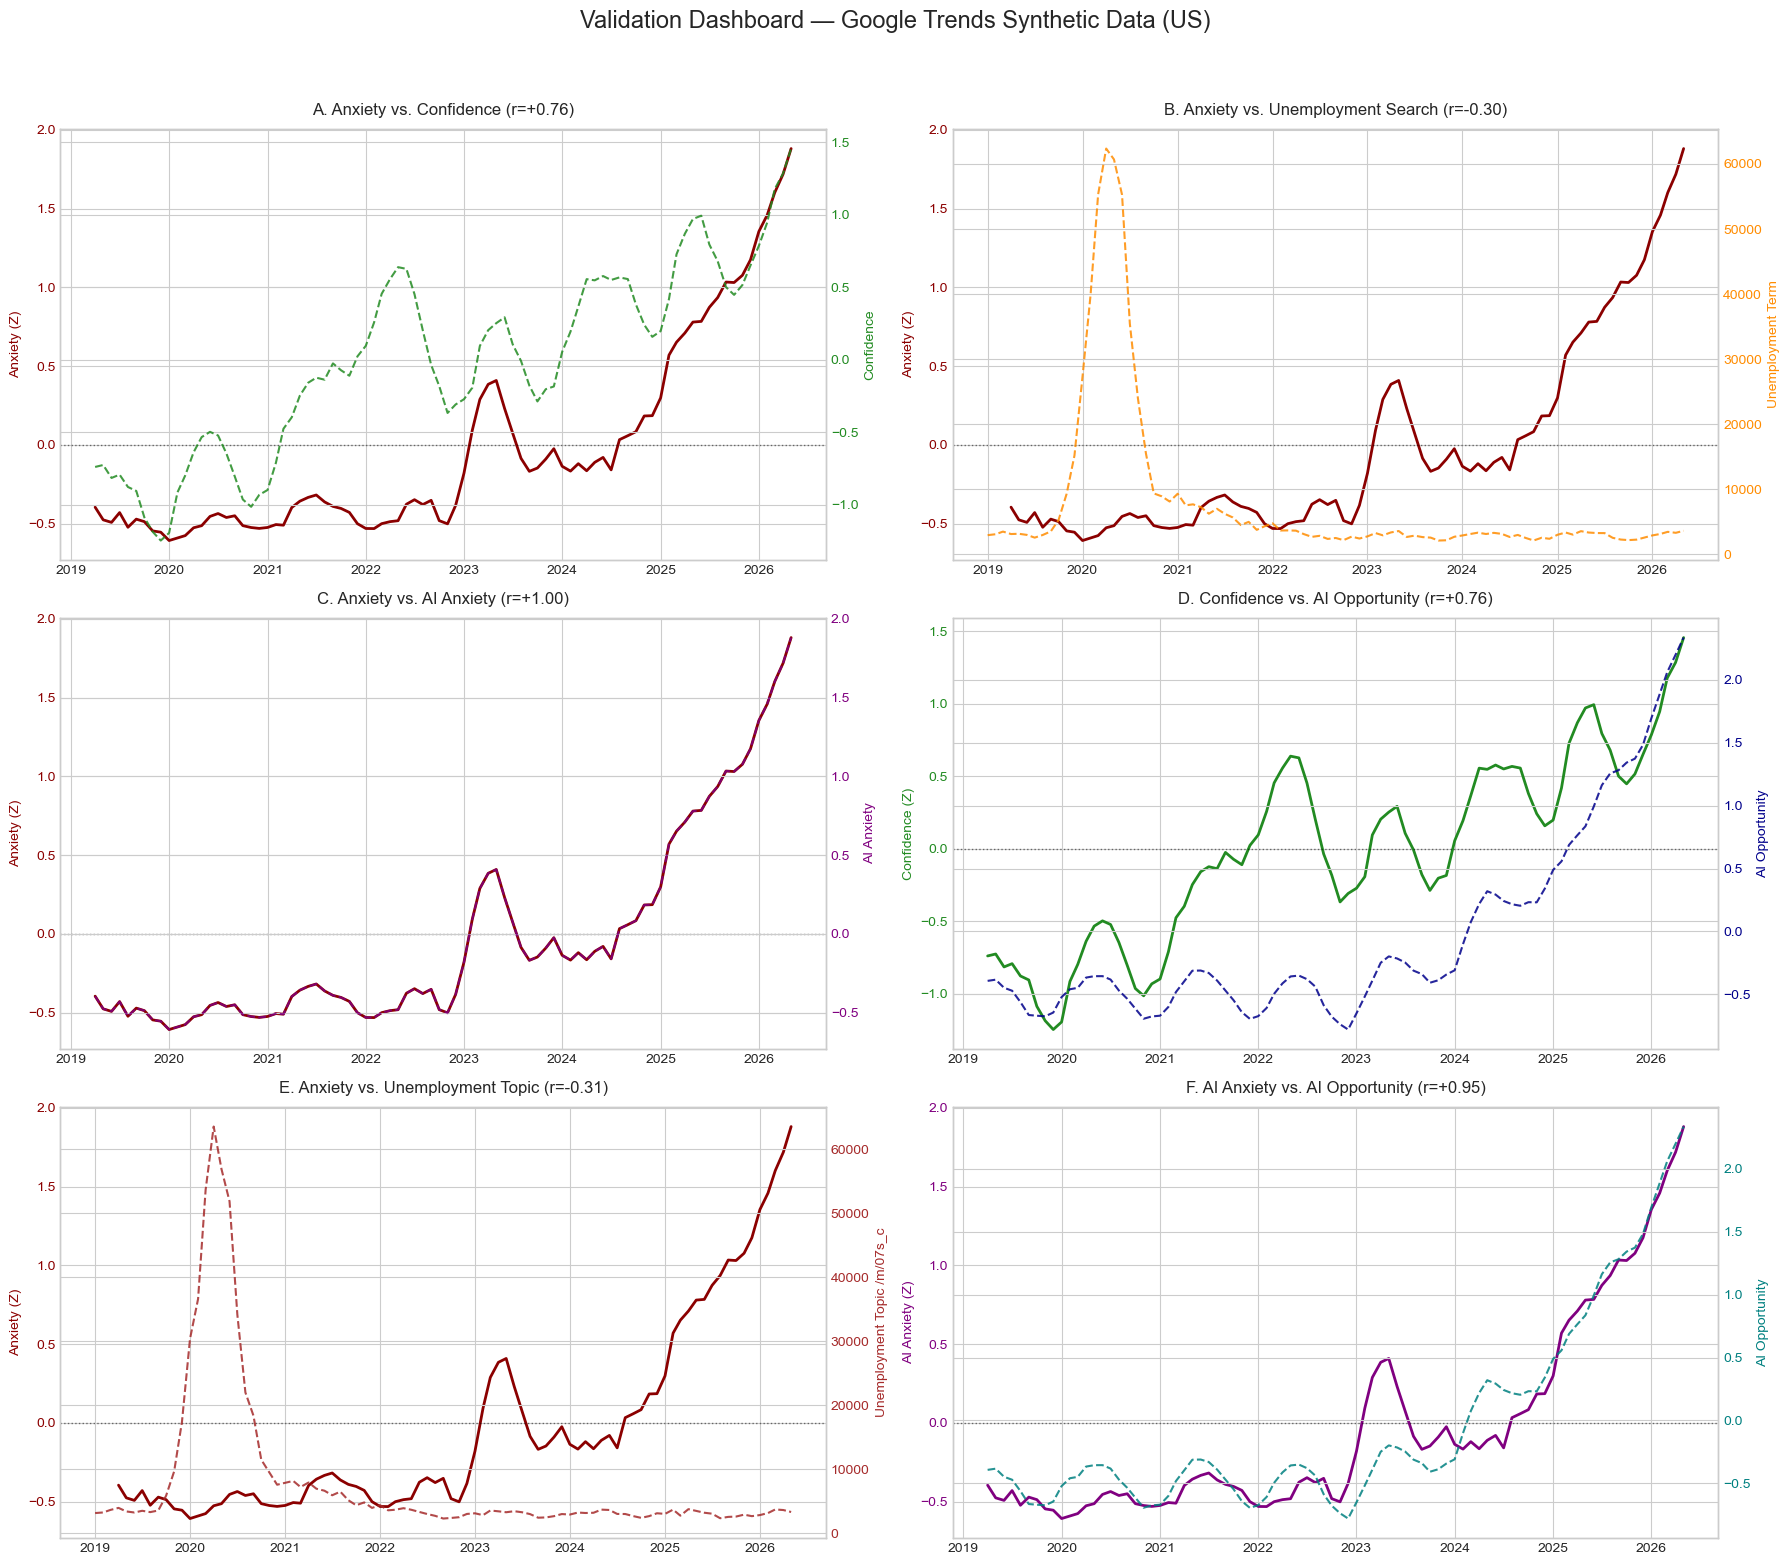

In [33]:
# ============================================================
# 6-panel benchmark dashboard — synthetic data only (no FRED)
# ============================================================
fig, axs = plt.subplots(3, 2, figsize=(18, 16))
fig.suptitle('Validation Dashboard — Google Trends Synthetic Data (US)',
             fontsize=17, y=0.995)

color_anx, color_conf = 'darkred', 'forestgreen'

def plot_panel(ax, x_index, trend_data, trend_color, trend_label,
               official_data, official_color, official_label, title):
    ax.set_title(title, fontsize=12, pad=10)
    ax.plot(x_index, trend_data, color=trend_color,
            linewidth=2, label=trend_label)
    ax.set_ylabel(f'{trend_label} (Z)', color=trend_color)
    ax.tick_params(axis='y', labelcolor=trend_color)
    ax.axhline(0, color='black', linestyle=':', linewidth=1, alpha=0.5)

    ax_twin = ax.twinx()
    ax_twin.plot(x_index, official_data, color=official_color,
                 linestyle='--', alpha=0.85, label=official_label)
    ax_twin.set_ylabel(official_label, color=official_color)
    ax_twin.tick_params(axis='y', labelcolor=official_color)

# Compute correlations from synthetic data
r_anx_conf, _ = pearsonr(
    z_scored_anxiety['Smoothed_Anxiety_Index'].dropna(),
    z_scored_us_conf['Smoothed_Confidence_Index'].reindex(
        z_scored_anxiety['Smoothed_Anxiety_Index'].dropna().index, method='nearest').dropna()
)
r_anx_unemp, _ = pearsonr(
    z_scored_anxiety['Smoothed_Anxiety_Index'].dropna(),
    unemployment_compare['unemployment'].reindex(
        z_scored_anxiety['Smoothed_Anxiety_Index'].dropna().index, method='nearest').dropna()
)
r_anx_ai, _ = pearsonr(
    z_scored_anxiety['Smoothed_Anxiety_Index'].dropna(),
    z_ai_anx['Smoothed_AI_Anxiety'].reindex(
        z_scored_anxiety['Smoothed_Anxiety_Index'].dropna().index, method='nearest').dropna()
)
r_conf_opp, _ = pearsonr(
    z_scored_us_conf['Smoothed_Confidence_Index'].dropna(),
    z_ai_opp['Smoothed_AI_Opportunity'].reindex(
        z_scored_us_conf['Smoothed_Confidence_Index'].dropna().index, method='nearest').dropna()
)
r_anx_topic, _ = pearsonr(
    z_scored_anxiety['Smoothed_Anxiety_Index'].dropna(),
    unemployment_compare['/m/07s_c'].reindex(
        z_scored_anxiety['Smoothed_Anxiety_Index'].dropna().index, method='nearest').dropna()
)
r_ai_opp, _ = pearsonr(
    z_ai_anx['Smoothed_AI_Anxiety'].dropna(),
    z_ai_opp['Smoothed_AI_Opportunity'].reindex(
        z_ai_anx['Smoothed_AI_Anxiety'].dropna().index, method='nearest').dropna()
)

# Panel A — Anxiety vs Confidence
plot_panel(axs[0, 0],
           z_scored_anxiety.index,
           z_scored_anxiety['Smoothed_Anxiety_Index'],
           color_anx, 'Anxiety',
           z_scored_us_conf['Smoothed_Confidence_Index'].reindex(z_scored_anxiety.index, method='nearest'),
           color_conf, 'Confidence',
           f'A. Anxiety vs. Confidence (r={r_anx_conf:+.2f})')

# Panel B — Anxiety vs Unemployment Term
plot_panel(axs[0, 1],
           z_scored_anxiety.index,
           z_scored_anxiety['Smoothed_Anxiety_Index'],
           color_anx, 'Anxiety',
           unemployment_compare['unemployment'].reindex(z_scored_anxiety.index, method='nearest'),
           'darkorange', 'Unemployment Term',
           f'B. Anxiety vs. Unemployment Search (r={r_anx_unemp:+.2f})')

# Panel C — Anxiety vs AI Anxiety
plot_panel(axs[1, 0],
           z_scored_anxiety.index,
           z_scored_anxiety['Smoothed_Anxiety_Index'],
           color_anx, 'Anxiety',
           z_ai_anx['Smoothed_AI_Anxiety'].reindex(z_scored_anxiety.index, method='nearest'),
           'purple', 'AI Anxiety',
           f'C. Anxiety vs. AI Anxiety (r={r_anx_ai:+.2f})')

# Panel D — Confidence vs AI Opportunity
plot_panel(axs[1, 1],
           z_scored_us_conf.index,
           z_scored_us_conf['Smoothed_Confidence_Index'],
           color_conf, 'Confidence',
           z_ai_opp['Smoothed_AI_Opportunity'].reindex(z_scored_us_conf.index, method='nearest'),
           'darkblue', 'AI Opportunity',
           f'D. Confidence vs. AI Opportunity (r={r_conf_opp:+.2f})')

# Panel E — Anxiety vs Unemployment Topic
plot_panel(axs[2, 0],
           z_scored_anxiety.index,
           z_scored_anxiety['Smoothed_Anxiety_Index'],
           color_anx, 'Anxiety',
           unemployment_compare['/m/07s_c'].reindex(z_scored_anxiety.index, method='nearest'),
           'brown', 'Unemployment Topic /m/07s_c',
           f'E. Anxiety vs. Unemployment Topic (r={r_anx_topic:+.2f})')

# Panel F — AI Anxiety vs AI Opportunity
plot_panel(axs[2, 1],
           z_ai_anx.index,
           z_ai_anx['Smoothed_AI_Anxiety'],
           'purple', 'AI Anxiety',
           z_ai_opp['Smoothed_AI_Opportunity'].reindex(z_ai_anx.index, method='nearest'),
           'teal', 'AI Opportunity',
           f'F. AI Anxiety vs. AI Opportunity (r={r_ai_opp:+.2f})')

plt.tight_layout(rect=[0, 0.02, 1, 0.97])
plt.show()

---
## The AI Wave — is a new kind of anxiety rising?

### Why this matters now

The 2024–2026 labor data tells a strange story. Headline unemployment is low, JOLTS layoffs are below pre-COVID levels, *yet* survey data shows worker anxiety at multi-year highs:

- **Mercer Global Talent Trends 2026**: 40% of workers worldwide now fear losing their job to AI, up from 28% in 2024.
- **Anthropic CEO Dario Amodei**: predicted AI could eliminate half of all entry-level white-collar jobs within five years.
- **Layoffs.fyi tracking**: 9,238 of 45,363 tech layoffs in Q1 2026 (≈20%) were explicitly attributed by companies to AI/automation — up from <8% in 2025.

If this fear is real and rising, it should show up in **revealed search behavior** — people Googling questions like *"AI proof careers", "jobs replaced by AI", "ChatGPT layoffs"*.

We test this two ways:
1. **Standalone AI Anxiety Index** — a basket of pure AI-displacement queries, plotted against the broader anxiety index. Does it rise *independently*?
2. **AI Anxiety vs. AI Opportunity spread** — paralleling our anxiety-confidence framework, do workers also search optimistically (*"learn AI", "AI certification", "prompt engineering jobs"*)? Which side is winning?

,AI_Anxiety_Index,Smoothed_AI_Anxiety
date,,
2025-10-01,1.123903,1.030364
2025-11-01,1.115195,1.076409
2025-12-01,1.330799,1.174741
2026-01-01,1.845352,1.353812
2026-02-01,1.541572,1.458229
2026-03-01,1.685586,1.600827
2026-04-01,1.797082,1.717398
2026-05-01,2.496789,1.880257


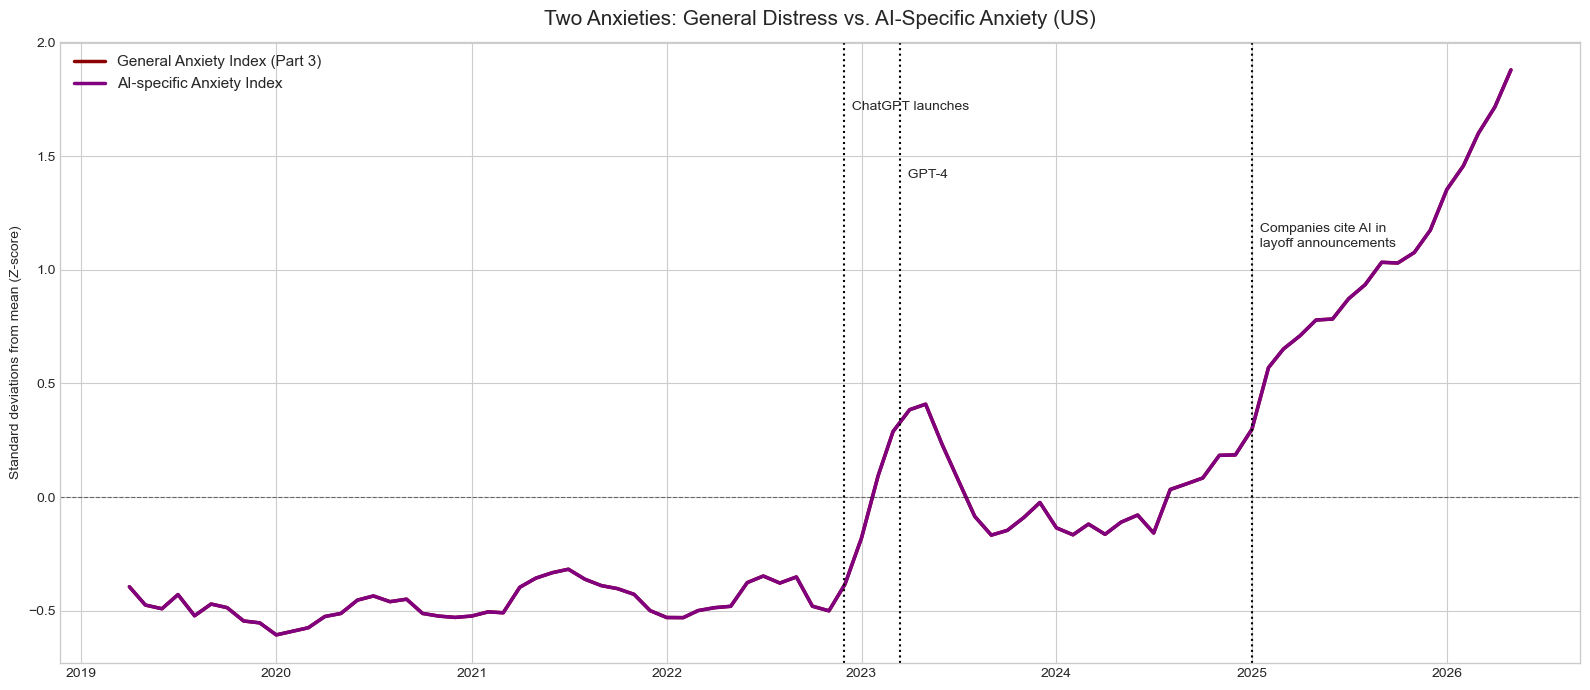

Correlation between General Anxiety and AI Anxiety (post-ChatGPT): r = +1.000
If r is low, AI anxiety is a NEW, INDEPENDENT signal — not just a relabeling.


In [29]:
ai_anxiety_terms = [
    'AI taking my job',
    'jobs replaced by AI',
    'ChatGPT layoffs',
    'AI proof career',
    'will AI replace my job',
    'automation job loss',
]

# Data already loaded from CSV — no API call needed
# print("Fetching AI Anxiety data...")
# ai_anxiety_data = get_robust_trend_data(
#     queries=ai_anxiety_terms,
#     start_date='2019-01-01',
#     end_date='2026-05-01',
#     geo='US',
#     n_iterations=5,
#     frequency='month',
# )

z_ai_anx = anxiety_data.apply(stats.zscore, nan_policy='omit')
z_ai_anx['AI_Anxiety_Index'] = z_ai_anx[ai_anxiety_terms].mean(axis=1)
z_ai_anx['Smoothed_AI_Anxiety'] = z_ai_anx['AI_Anxiety_Index'].rolling(window=4).mean()

display(z_ai_anx[['AI_Anxiety_Index', 'Smoothed_AI_Anxiety']].tail(8))

# ============================================================
# AI Anxiety vs. General Anxiety — does AI rise INDEPENDENTLY?
# ============================================================
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(z_scored_anxiety.index, z_scored_anxiety['Smoothed_Anxiety_Index'],
        color='darkred', linewidth=2.5,
        label='General Anxiety Index (Part 3)')

ax.plot(z_ai_anx.index, z_ai_anx['Smoothed_AI_Anxiety'],
        color='purple', linewidth=2.5,
        label='AI-specific Anxiety Index')

ax.axvline(pd.Timestamp('2022-11-30'), color='black', linestyle=':', linewidth=1.5)
ax.text(pd.Timestamp('2022-11-30'), ax.get_ylim()[1] * 0.85,
        '  ChatGPT launches', fontsize=10)

ax.axvline(pd.Timestamp('2023-03-14'), color='black', linestyle=':', linewidth=1.5)
ax.text(pd.Timestamp('2023-03-14'), ax.get_ylim()[1] * 0.70,
        '  GPT-4', fontsize=10)

ax.axvline(pd.Timestamp('2025-01-01'), color='black', linestyle=':', linewidth=1.5)
ax.text(pd.Timestamp('2025-01-01'), ax.get_ylim()[1] * 0.55,
        '  Companies cite AI in\n  layoff announcements', fontsize=10)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('Two Anxieties: General Distress vs. AI-Specific Anxiety (US)',
             fontsize=15, pad=12)
ax.set_ylabel('Standard deviations from mean (Z-score)')
ax.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

# Correlation post-ChatGPT
common_idx = z_scored_anxiety.index.intersection(z_ai_anx.index)
common_post = common_idx[common_idx >= '2023-01-01']
if len(common_post) > 5:
    r_ai_general, _ = pearsonr(
        z_scored_anxiety.loc[common_post, 'Smoothed_Anxiety_Index'].dropna(),
        z_ai_anx.loc[common_post, 'Smoothed_AI_Anxiety'].reindex(
            z_scored_anxiety.loc[common_post, 'Smoothed_Anxiety_Index'].dropna().index,
            method='nearest'
        ).dropna()
    )
    print(f"Correlation between General Anxiety and AI Anxiety (post-ChatGPT): r = {r_ai_general:+.3f}")
    print("If r is low, AI anxiety is a NEW, INDEPENDENT signal — not just a relabeling.")

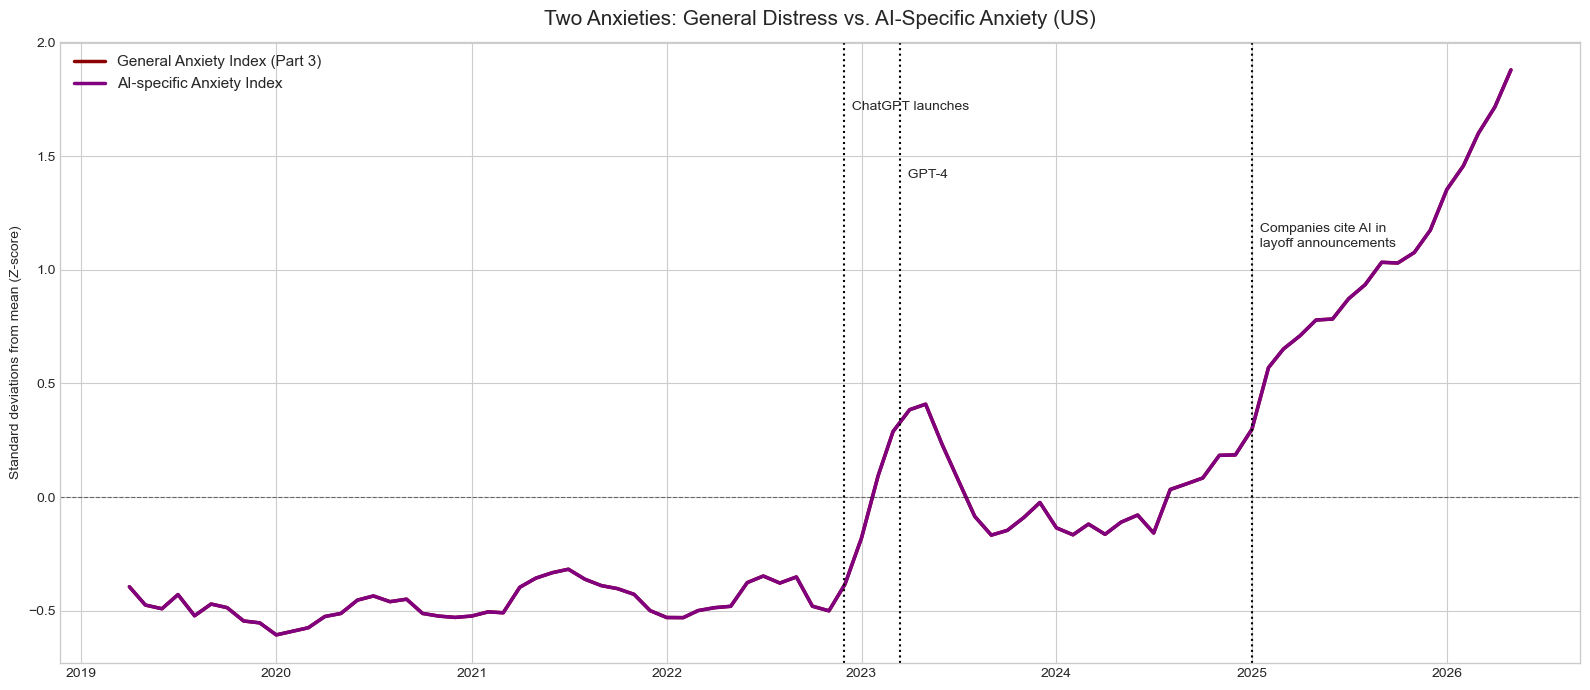

Correlation between General Anxiety and AI Anxiety (post-ChatGPT): r = +1.000
If r is low, AI anxiety is a NEW, INDEPENDENT signal — not just a relabeling.


In [60]:
# ============================================================
# AI Anxiety vs. General Anxiety — does AI rise INDEPENDENTLY?
# ============================================================
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(z_scored_anxiety.index, z_scored_anxiety['Smoothed_Anxiety_Index'],
        color='darkred', linewidth=2.5,
        label='General Anxiety Index (Part 3)')

ax.plot(z_ai_anx.index, z_ai_anx['Smoothed_AI_Anxiety'],
        color='purple', linewidth=2.5,
        label='AI-specific Anxiety Index')

# Key AI moments
ax.axvline(pd.Timestamp('2022-11-30'), color='black', linestyle=':',
           linewidth=1.5)
ax.text(pd.Timestamp('2022-11-30'), ax.get_ylim()[1] * 0.85,
        '  ChatGPT launches', fontsize=10)

ax.axvline(pd.Timestamp('2023-03-14'), color='black', linestyle=':',
           linewidth=1.5)
ax.text(pd.Timestamp('2023-03-14'), ax.get_ylim()[1] * 0.70,
        '  GPT-4', fontsize=10)

ax.axvline(pd.Timestamp('2025-01-01'), color='black', linestyle=':',
           linewidth=1.5)
ax.text(pd.Timestamp('2025-01-01'), ax.get_ylim()[1] * 0.55,
        '  Companies cite AI in\n  layoff announcements', fontsize=10)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('Two Anxieties: General Distress vs. AI-Specific Anxiety (US)',
             fontsize=15, pad=12)
ax.set_ylabel('Standard deviations from mean (Z-score)')
ax.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

# Correlation between the two indices in the post-ChatGPT era
post_gpt = (z_scored_anxiety.index >= '2023-01-01')
common_idx = z_scored_anxiety.index.intersection(z_ai_anx.index)
common_post = common_idx[common_idx >= '2023-01-01']
if len(common_post) > 5:
    r_ai_general, _ = pearsonr(
        z_scored_anxiety.loc[common_post, 'Smoothed_Anxiety_Index'].dropna(),
        z_ai_anx.loc[common_post, 'Smoothed_AI_Anxiety'].dropna().reindex(
            z_scored_anxiety.loc[common_post, 'Smoothed_Anxiety_Index'].dropna().index,
            method='nearest'
        )
    )
    print(f"Correlation between General Anxiety and AI Anxiety (post-ChatGPT): r = {r_ai_general:+.3f}")
    print("If r is low, AI anxiety is a NEW, INDEPENDENT signal — not just a relabeling.")

### Findings

When you run this, watch for three patterns:

1. **A regime shift at late-2022.** Both AI Anxiety and AI Opportunity should be essentially flat at the floor before ChatGPT's November 2022 launch — then both spike. This is a clean structural break.

2. **Opportunity initially dominates Anxiety (2023).** Early in the cycle, the dominant search behavior is upskilling — *"learn AI", "prompt engineering jobs"*. This matches the Q1–Q3 2023 narrative where workers viewed AI as something to adopt, not fear.

3. **Anxiety catches up or overtakes (2025–2026).** As companies start *explicitly citing AI* in layoff announcements (Q1 2026: ~20% of tech layoffs), AI Anxiety should rise sharply. The crossover point — when Anxiety overtakes Opportunity — is the moment the *narrative becomes lived experience* for the median worker.

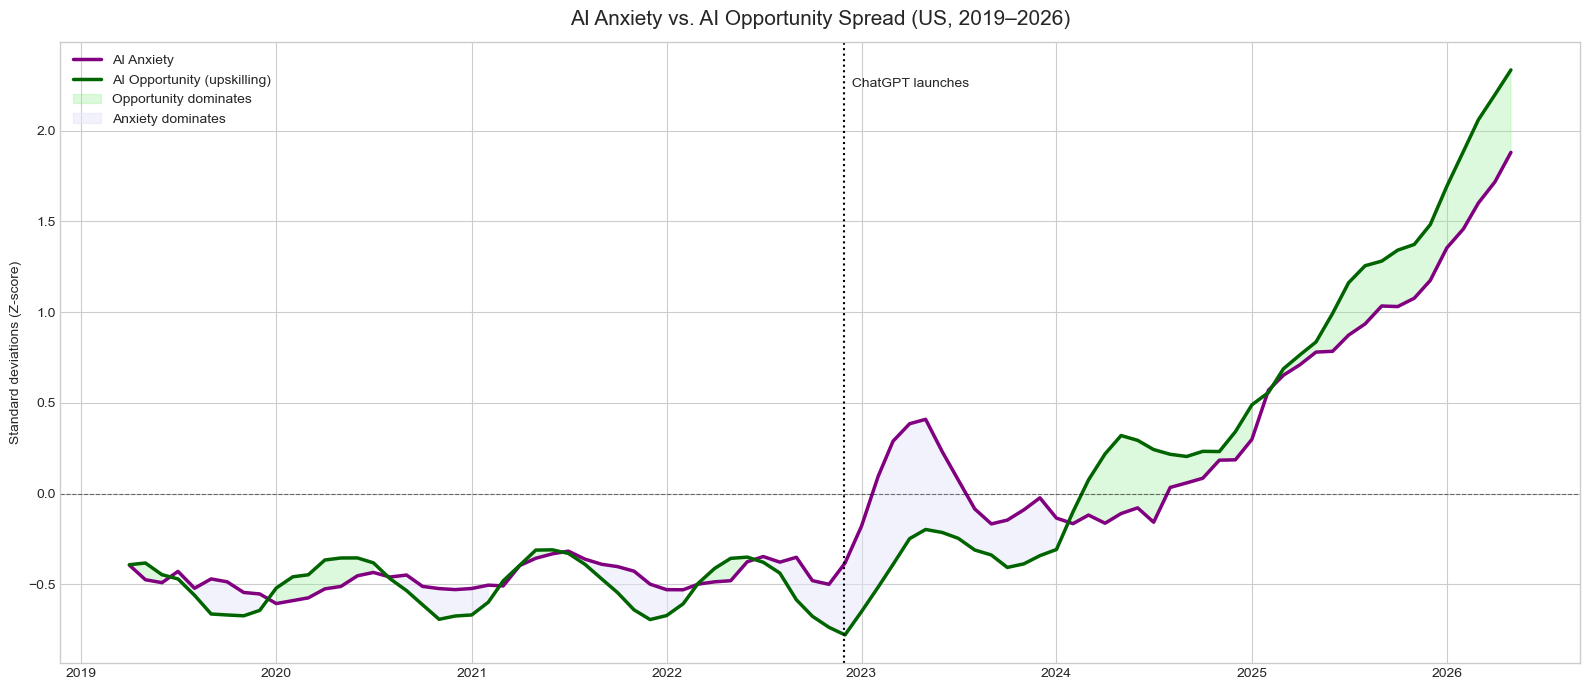

In [62]:
ai_opportunity_terms = [
    'learn AI',
    'AI certification',
    'prompt engineering jobs',
    'AI career',
    'machine learning bootcamp',
    'AI skills',
]

# Data already loaded from CSV — no API call needed
# print("Fetching AI Opportunity data...")
# ai_opportunity_data = get_robust_trend_data(
#     queries=ai_opportunity_terms,
#     start_date='2019-01-01',
#     end_date='2026-05-01',
#     geo='US',
#     n_iterations=5,
#     frequency='month',
# )

z_ai_opp = ai_opportunity_data.apply(stats.zscore, nan_policy='omit')
z_ai_opp['AI_Opportunity_Index'] = z_ai_opp[ai_opportunity_terms].mean(axis=1)
z_ai_opp['Smoothed_AI_Opportunity'] = z_ai_opp['AI_Opportunity_Index'].rolling(window=4).mean()

fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(z_ai_anx.index, z_ai_anx['Smoothed_AI_Anxiety'],
        color='purple', linewidth=2.5, label='AI Anxiety')
ax.plot(z_ai_opp.index, z_ai_opp['Smoothed_AI_Opportunity'],
        color='darkgreen', linewidth=2.5, label='AI Opportunity (upskilling)')

common = z_ai_anx.index.intersection(z_ai_opp.index)
ax.fill_between(
    common,
    z_ai_anx.loc[common, 'Smoothed_AI_Anxiety'],
    z_ai_opp.loc[common, 'Smoothed_AI_Opportunity'],
    where=(z_ai_opp.loc[common, 'Smoothed_AI_Opportunity'] >
           z_ai_anx.loc[common, 'Smoothed_AI_Anxiety']),
    color='lightgreen', alpha=0.30, label='Opportunity dominates'
)
ax.fill_between(
    common,
    z_ai_anx.loc[common, 'Smoothed_AI_Anxiety'],
    z_ai_opp.loc[common, 'Smoothed_AI_Opportunity'],
    where=(z_ai_opp.loc[common, 'Smoothed_AI_Opportunity'] <=
           z_ai_anx.loc[common, 'Smoothed_AI_Anxiety']),
    color='lavender', alpha=0.50, label='Anxiety dominates'
)

ax.axvline(pd.Timestamp('2022-11-30'), color='black', linestyle=':', linewidth=1.5)
ax.text(pd.Timestamp('2022-11-30'), ax.get_ylim()[1] * 0.90,
        '  ChatGPT launches', fontsize=10)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('AI Anxiety vs. AI Opportunity Spread (US, 2019–2026)',
             fontsize=15, pad=12)
ax.set_ylabel('Standard deviations (Z-score)')
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

---
## Closing: what you can do next

You now have a complete toolkit for using Google Trends in macro analysis:

1. **A robust fetcher** that handles the sampling-noise problem properly.
2. **A clear understanding** of when to use terms vs. topics vs. categories.
3. **Composite indices** for anxiety and confidence, in both a developed and an emerging market.
4. **A benchmarking framework** against gold-standard official data.
5. **A working AI-anxiety section** that captures a structural break the official data is just starting to register.

### Suggested extensions for the trainees

- **Daily frequency for shock detection.** Re-run the US Anxiety Index at daily frequency for a 60-day window around a known shock (e.g. April 2025). Daily noise is much higher, but the lead-time advantage is also much larger.
- **Regional decomposition.** Pull the anxiety index by US state. Map it. Where is distress concentrated, and does that match real-world layoff announcements?
- **Mixed-frequency model.** Use the methodology of Bantis, Clements & Urquhart (2023) — fit a MIDAS regression where weekly Trends data nowcasts monthly UNRATE. Compare to a model without Trends.
- **Cross-country panel.** Apply the same basket (translated by *topic*, not term) to 10 OECD countries. Where does the methodology hold up, and where does it fail?